# Import Library

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Dataset

In [173]:
df_train = pd.read_csv('./dataset/train_dataset.csv')
df_test = pd.read_csv('./dataset/test_dataset_no_y.csv')

In [174]:
df_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.407166,E,W,2.0,M,C,1.127628,-0.657689,-0.415323,76.124758,20.710704
1,44.417166,M,W,1.0,H,C,0.957628,-0.667689,-0.475323,85.834758,94.202404
2,28.047166,M,W,4.0,L,R,0.717628,-1.107689,-0.385323,13.814758,43.043004
3,-0.462834,NaN,W,2.0,L,C,1.717628,-1.547689,-0.425323,29.344758,7.956004
4,42.957166,M,W,3.0,M,C,0.747628,-1.847689,-0.135323,NaN,62.397804


In [175]:
df_test.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,16.787166,N,W,2.0,L,C,2.807628,-0.687689,-0.175323,103.314758
1,38.137166,M,NaN,1.0,M,C,2.197628,-0.617689,-0.195323,14.644758
2,20.797166,E,W,1.0,M,S,3.007628,-0.687689,-0.235323,41.574758
3,15.577166,A,W,4.0,M,C,0.707628,-0.827689,-0.125323,107.614758
4,44.677166,M,W,4.0,L,C,3.027628,-0.447689,-0.345323,92.434758


In [176]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      757 non-null    float64
 1   x2      760 non-null    object 
 2   x3      762 non-null    object 
 3   x4      764 non-null    float64
 4   x5      758 non-null    object 
 5   x6      761 non-null    object 
 6   x7      761 non-null    float64
 7   x8      756 non-null    float64
 8   x9      763 non-null    float64
 9   x10     758 non-null    float64
 10  y       758 non-null    float64
dtypes: float64(7), object(4)
memory usage: 68.9+ KB


In [177]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      186 non-null    float64
 1   x2      183 non-null    object 
 2   x3      182 non-null    object 
 3   x4      180 non-null    float64
 4   x5      185 non-null    object 
 5   x6      182 non-null    object 
 6   x7      183 non-null    float64
 7   x8      187 non-null    float64
 8   x9      181 non-null    float64
 9   x10     185 non-null    float64
dtypes: float64(6), object(4)
memory usage: 15.2+ KB


## Memisahkkan Data Kategorikal dengan Numerik

In [178]:
numeric_cols = df_train.select_dtypes(['number']).drop(['x4', 'y'], axis=1).columns.to_list()

categorical_cols = df_train.select_dtypes(['object']).columns.to_list()
categorical_cols.append('x4')

In [179]:
numeric_cols

['x1', 'x7', 'x8', 'x9', 'x10']

In [180]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

# Data Cleaning

## Cek Duplikat

Tahap ini dilakukan pengecekan data duplikat pada dataset train dan test untuk memastikan tidak ada data yang double atau tercatat lebih dari satu kali.

In [181]:
df_train.duplicated().sum()

np.int64(0)

In [182]:
df_test.duplicated().sum()

np.int64(0)

Pengecekan data duplikat dilakukan menggunakan fungsi duplicated() pada dataset train dan test, kemudian jumlah data duplikat dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada kedua dataset tersebut, yang ditandai dengan nilai output 0.

## Cek Missing Value

Tahap ini dilakukan pengecekan data yang hilang pada dataset train dan test untuk memastikan tidak terdapat nilai kosong (missing values) yang dapat memengaruhi proses analisis dan pemodelan data.

In [183]:
df_train.isna().sum() 

x1     43
x2     40
x3     38
x4     36
x5     42
x6     39
x7     39
x8     44
x9     37
x10    42
y      42
dtype: int64

In [184]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

Pengecekan data yang hilang dilakukan menggunakan fungsi isna() pada dataset train dan test, kemudian jumlah data yang hilang dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa cukup banyak data yang hilang pada dataset train maupun test, sehingga terdapat 2 pilihan yang harus dilakukan yaitu menghapus baris pada data yang hilang atau melakukan imputasi pada data yang hilang. Karena pada kedua dataset cukup banyak, melakukan imputasi menggunakan mean() atau median() pada variabel numerik seharusnya tidak disarankan karena dapat merusak keaslian data, namun untuk case pada project ini di mana dataset merupakan dataset dummy, jadi saya akan mengatasi missing value dengan melakukan imputasi

## Handle Outlier

<Axes: >

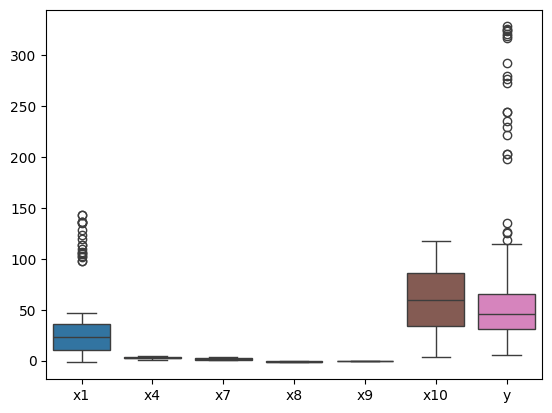

In [185]:
sns.boxplot(df_train)

In [186]:
def handle_outliers_fixed(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    df_result = df.copy()
    
    for col in numeric_cols:
        Q1 = df_result[col].quantile(0.25)
        Q3 = df_result[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        median_value = df_result[col].median()
        
        # Penggantian nilai hanya pada kolom numerik
        outlier_mask = (df_result[col] < lower_bound) | (df_result[col] > upper_bound)
        df_result[col] = df_result[col].where(~outlier_mask, median_value)

    return df_result

df_train = handle_outliers_fixed(df_train)

<Axes: >

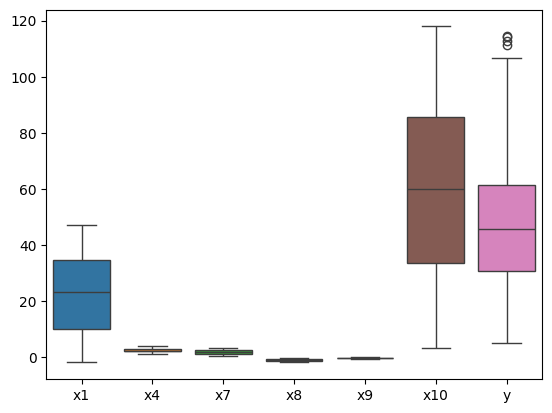

In [187]:
sns.boxplot(df_train)

In [188]:
df_train.isna().sum()

x1     43
x2     40
x3     38
x4     36
x5     42
x6     39
x7     39
x8     44
x9     37
x10    42
y      42
dtype: int64

## Cek Distribusi Data

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: >]], dtype=object)

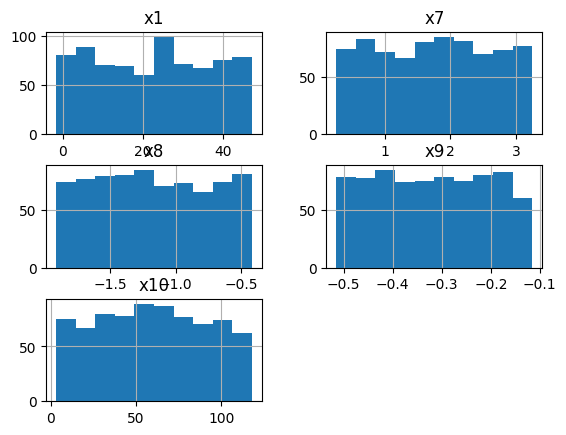

In [189]:
df_train[numeric_cols].hist()

Dilihat dari hasil visualisasi Histogram pada gambar di atas keseluruhan variabel bertipe data numerik memiliki distribusi yang cukup normal sehingga untuk melakukan imputasi pada missing value dapat menggunakan mean

## Handle Missing Value

In [190]:
df_train.isna().sum()

x1     43
x2     40
x3     38
x4     36
x5     42
x6     39
x7     39
x8     44
x9     37
x10    42
y      42
dtype: int64

In [191]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Numerik

In [192]:
df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].mean())

In [193]:
df_train[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

In [194]:
df_test[numeric_cols] = df_test[numeric_cols].fillna(df_test[numeric_cols].mean())

In [195]:
df_test[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Kategorikal

Untuk menangani missing value pada variabel yang bertipe data kategorikal kita dapat menggunakan modus dari variabel tersebut

In [196]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

In [197]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
print('===============================================================================')
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())

Jumlah Missing Value pada Data Training Variabel x2:  40
Jumlah Missing Value pada Data Training Variabel x3:  38
Jumlah Missing Value pada Data Training Variabel x5:  42
Jumlah Missing Value pada Data Training Variabel x6:  39
Jumlah Missing Value pada Data Training Variabel x4:  36
Jumlah Missing Value pada Data Testing Variabel x2:  10
Jumlah Missing Value pada Data Testing Variabel x3:  11
Jumlah Missing Value pada Data Testing Variabel x5:  8
Jumlah Missing Value pada Data Testing Variabel x6:  11
Jumlah Missing Value pada Data Testing Variabel x4:  13


In [198]:
print(df_train['x2'].value_counts())
print(df_test['x2'].value_counts())

x2
A    303
M    216
E    162
N     79
Name: count, dtype: int64
x2
A    66
M    64
E    39
N    14
Name: count, dtype: int64


In [199]:
df_train['x2'] = df_train['x2'].fillna('A')
df_test['x2'] = df_test['x2'].fillna('A')

In [200]:
print(df_train['x3'].value_counts())
print(df_test['x3'].value_counts())

x3
W    762
Name: count, dtype: int64
x3
W    182
Name: count, dtype: int64


In [201]:
df_train['x3'] = df_train['x3'].fillna('W')
df_test['x3'] = df_test['x3'].fillna('W')

In [202]:
print(df_train['x5'].value_counts())
print(df_test['x5'].value_counts())

x5
L    313
M    291
H    154
Name: count, dtype: int64
x5
L    83
M    77
H    25
Name: count, dtype: int64


In [203]:
df_train['x5'] = df_train['x5'].fillna('L')
df_test['x5'] = df_test['x5'].fillna('L')

In [204]:
print(df_train['x4'].value_counts())
print(df_test['x4'].value_counts())

x4
3.0    211
2.0    201
1.0    187
4.0    165
Name: count, dtype: int64
x4
4.0    53
1.0    49
2.0    40
3.0    38
Name: count, dtype: int64


In [205]:
df_train['x4'] = df_train['x4'].fillna(3)
df_test['x4'] = df_test['x4'].fillna(4)

In [206]:
print(df_train['x6'].value_counts())
print(df_test['x6'].value_counts())

x6
C    531
R    191
S     39
Name: count, dtype: int64
x6
C    133
R     33
S     16
Name: count, dtype: int64


In [207]:
df_train['x6'] = df_train['x6'].fillna('C')
df_test['x6'] = df_test['x6'].fillna('C')

In [208]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
print('===============================================================================')
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())

Jumlah Missing Value pada Data Training Variabel x2:  0
Jumlah Missing Value pada Data Training Variabel x3:  0
Jumlah Missing Value pada Data Training Variabel x5:  0
Jumlah Missing Value pada Data Training Variabel x6:  0
Jumlah Missing Value pada Data Training Variabel x4:  0
Jumlah Missing Value pada Data Testing Variabel x2:  0
Jumlah Missing Value pada Data Testing Variabel x3:  0
Jumlah Missing Value pada Data Testing Variabel x5:  0
Jumlah Missing Value pada Data Testing Variabel x6:  0
Jumlah Missing Value pada Data Testing Variabel x4:  0


# Exploratory Data Analysis

## Cek Korelasi

Melakukan Analisis Korelasi untuk melihat variabel mana yang memiliki hubungan antara satu dengan yang lain

## Variabel Numerik

In [209]:
df_train[numeric_cols]

,x1,x7,x8,x9,x10
0,0.407166,1.127628,-0.657689,-0.415323,76.124758
1,44.417166,0.957628,-0.667689,-0.475323,85.834758
2,28.047166,0.717628,-1.107689,-0.385323,13.814758
3,-0.462834,1.717628,-1.547689,-0.425323,29.344758
4,42.957166,0.747628,-1.847689,-0.135323,59.538307
...,...,...,...,...,...
795,18.237166,2.857628,-1.727689,-0.435323,82.144758
796,37.787166,2.147628,-1.747689,-0.315323,32.374758
797,36.127166,0.437628,-0.857689,-0.185323,62.894758
798,32.477166,2.447628,-1.207689,-0.465323,77.094758


In [210]:
df_numeric_corr = df_train[['x1', 'x7', 'x8', 'x9', 'x10', 'y']].corr(method='pearson')
df_numeric_corr

,x1,x7,x8,x9,x10,y
x1,1.000000,0.049941,-0.081803,0.022116,-0.032002,0.681552
x7,0.049941,1.000000,-0.004659,-0.038496,-0.009381,0.038164
x8,-0.081803,-0.004659,1.000000,0.032814,0.008887,0.354977
x9,0.022116,-0.038496,0.032814,1.000000,-0.033098,0.274892
x10,-0.032002,-0.009381,0.008887,-0.033098,1.000000,0.327092
y,0.681552,0.038164,0.354977,0.274892,0.327092,1.000000


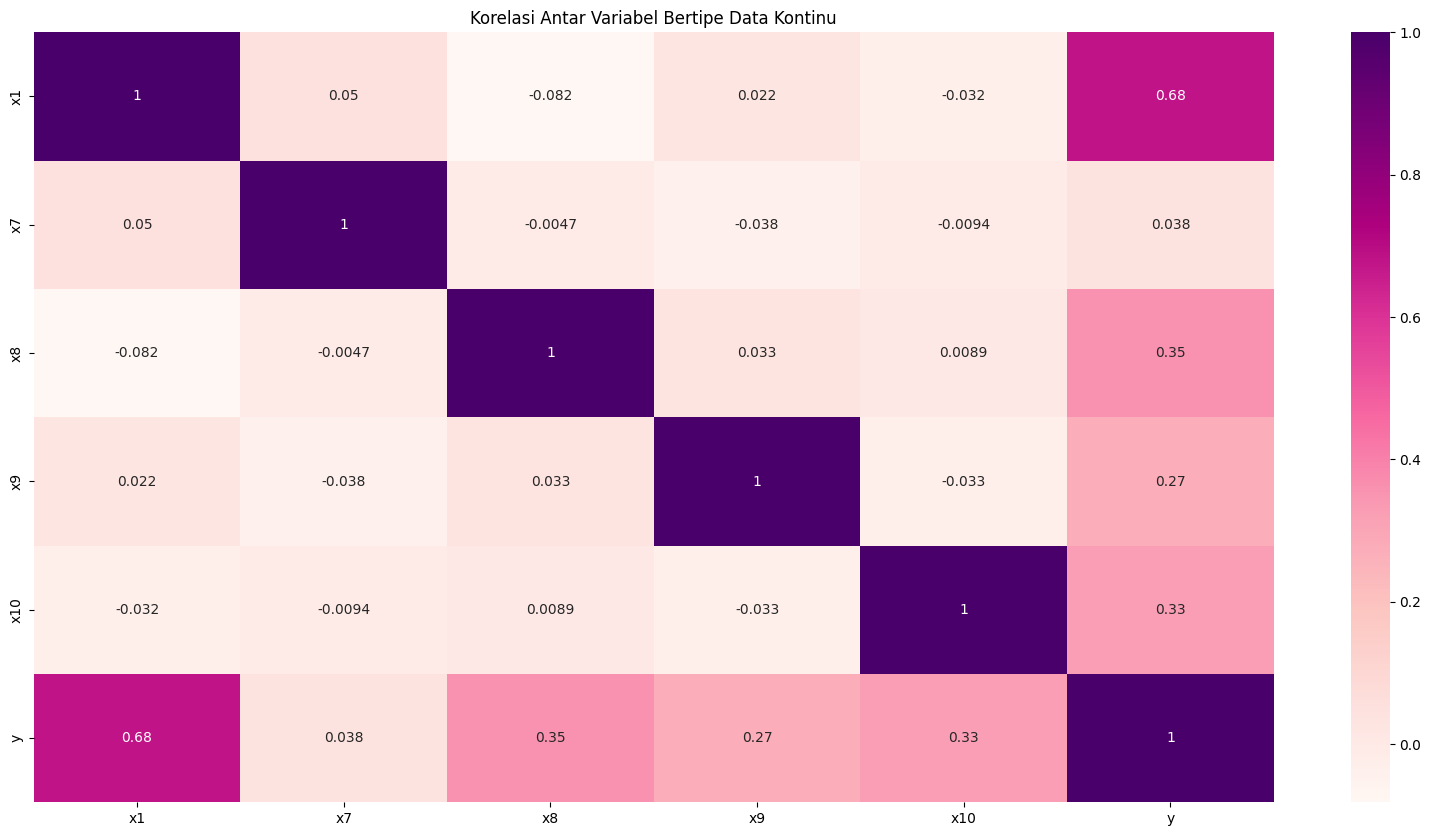

In [211]:
plt.figure(figsize=(20, 10))
plt.title('Korelasi Antar Variabel Bertipe Data Kontinu')
sns.heatmap(df_numeric_corr, annot=True, cmap='RdPu')
plt.show()

Berdasarkan visualisasi heatmap, terlihat bahwa variabel X7 tidak memiliki hubungan yang kuat dengan variabel Y, sehingga variabel X7 berpotensi untuk dihapus pada tahap feature Selection.

## Variabel Kategorik

In [212]:
df_train.describe()

,x1,x4,x7,x8,x9,x10,y
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,758.000000
mean,22.428025,2.487500,1.749244,-1.179051,-0.323344,59.538307,47.902945
std,13.849311,1.063606,0.840013,0.419517,0.113045,30.958087,22.926218
min,-1.642834,1.000000,0.257628,-1.917689,-0.515323,3.134758,5.120804
25%,10.337166,2.000000,1.037628,-1.537689,-0.415323,34.652258,30.710379
50%,22.428025,3.000000,1.749244,-1.179051,-0.323344,59.538307,45.777504
75%,34.004666,3.000000,2.425128,-0.827689,-0.235323,84.572258,61.516304
max,47.117166,4.000000,3.247628,-0.417689,-0.115323,117.924758,114.482004


## Menghapus Missing Value pada Variabel Dependen

In [213]:
df_train = df_train.dropna()

In [214]:
df_train.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
y      0
dtype: int64

In [215]:
df_test.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

## Encode Data Bertipe Kategorikal

Karena Variabel kategorikal skala datanya nominal, maka saya melakukan One Hot Encoding untuk mengubah data menjadi bentuk numerik

In [216]:
le = LabelEncoder()

# Encode variabel kategorikal
df_train['x2'] = le.fit_transform(df_train['x2'])
df_train['x5'] = le.fit_transform(df_train['x5'])
df_train['x3'] = le.fit_transform(df_train['x3'])
df_train['x6'] = le.fit_transform(df_train['x6'])

df_train

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.407166,1,0,2.0,2,0,1.127628,-0.657689,-0.415323,76.124758,20.710704
1,44.417166,2,0,1.0,0,0,0.957628,-0.667689,-0.475323,85.834758,94.202404
2,28.047166,2,0,4.0,1,1,0.717628,-1.107689,-0.385323,13.814758,43.043004
3,-0.462834,0,0,2.0,1,0,1.717628,-1.547689,-0.425323,29.344758,7.956004
4,42.957166,2,0,3.0,2,0,0.747628,-1.847689,-0.135323,59.538307,62.397804
...,...,...,...,...,...,...,...,...,...,...,...
795,18.237166,0,0,4.0,0,1,2.857628,-1.727689,-0.435323,82.144758,30.756604
796,37.787166,0,0,2.0,2,0,2.147628,-1.747689,-0.315323,32.374758,37.879104
797,36.127166,1,0,1.0,1,0,0.437628,-0.857689,-0.185323,62.894758,87.348204
798,32.477166,2,0,1.0,2,0,2.447628,-1.207689,-0.465323,77.094758,55.274904


In [217]:
df_test['x2'] = le.fit_transform(df_test['x2'])
df_test['x5'] = le.fit_transform(df_test['x5'])
df_test['x3'] = le.fit_transform(df_test['x3'])
df_test['x6'] = le.fit_transform(df_test['x6'])

df_test

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,16.787166,3,0,2.0,1,0,2.807628,-0.687689,-0.175323,103.314758
1,38.137166,2,0,1.0,2,0,2.197628,-0.617689,-0.195323,14.644758
2,20.797166,1,0,1.0,2,2,3.007628,-0.687689,-0.235323,41.574758
3,15.577166,0,0,4.0,2,0,0.707628,-0.827689,-0.125323,107.614758
4,44.677166,2,0,4.0,1,0,3.027628,-0.447689,-0.345323,92.434758
...,...,...,...,...,...,...,...,...,...,...
188,42.487166,0,0,4.0,2,1,0.907628,-0.637689,-0.355323,66.764758
189,-1.162834,2,0,4.0,0,0,2.697628,-1.147689,-0.435323,85.934758
190,-1.622834,0,0,3.0,1,1,2.217628,-0.927689,-0.305323,10.884758
191,2.137166,0,0,4.0,1,1,1.877628,-1.627689,-0.245323,56.104758


In [218]:
# df_test = pd.get_dummies(data=df_test, columns=['x2'],dtype='int64', prefix='x2', drop_first=True)
# df_test = pd.get_dummies(data=df_test, columns=['x5'],dtype='int64', prefix='x5', drop_first=True)
# df_test = pd.get_dummies(data=df_test, columns=['x3'],dtype='int64', prefix='x3')
# df_test = pd.get_dummies(data=df_test, columns=['x6'],dtype='int64', prefix='x6', drop_first=True)
# df_test

## Scaling Data

Melakukan Scaling pada Variabel prediktor supaya skala data seragam

$$
z = \frac{x - \mu}{\sigma}
$$

dengan:
- $x$ : nilai asli data  
- $\mu$ : rata-rata (mean) data  
- $\sigma$ : standar deviasi data  
- $z$ : nilai hasil scaling

In [219]:
scaler = StandardScaler()
df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = scaler.fit_transform(df_test[numeric_cols])

In [220]:
df_train

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,-1.598568,1,0,2.0,2,0,-0.732593,1.248874,-0.823942,0.541960,20.710704
1,1.590987,2,0,1.0,0,0,-0.935253,1.225098,-1.356354,0.854185,94.202404
2,0.404597,2,0,4.0,1,1,-1.221361,0.178953,-0.557736,-1.461622,43.043004
3,-1.661620,0,0,2.0,1,0,-0.029245,-0.867192,-0.912677,-0.962254,7.956004
4,1.485176,2,0,3.0,2,0,-1.185597,-1.580473,1.660647,0.008621,62.397804
...,...,...,...,...,...,...,...,...,...,...,...
795,-0.306367,0,0,4.0,0,1,1.329768,-1.295160,-1.001412,0.735533,30.756604
796,1.110488,0,0,2.0,2,0,0.483366,-1.342712,0.063412,-0.864824,37.879104
797,0.990182,1,0,1.0,1,0,-1.555154,0.773354,1.216971,0.116548,87.348204
798,0.725654,2,0,1.0,2,0,0.841000,-0.058807,-1.267618,0.573150,55.274904


# Modelling

Melakukan Feature Selection di mana Feature Selection iini menyeleksi fitur yang tidak signifikan

In [221]:
X = df_train.drop(['y', 'x7', 'x3', 'x4'], axis=1)
y = df_train['y']
X_test = df_test.drop(['x7', 'x3', 'x4'], axis=1)

Mengubah fungsi menjadi fungsi polinomial kuadrat, karena dari percobaan sebelum-sebelumnya hasil OLS dari penggunaan LinearRegression kurang memuaskan

In [222]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)
X_test_poly = poly.fit_transform(X_test)

Fungsi Polinomial derajat dua dilakukan untuk menambahkan fitur kuadrat dari setiap variabel prediktor sehingga model mampu menangkap pola yang non-linear, saya sudah melakukan percobaan terhadap fungsi polinomial derajat 3 dan 4 yang dihasilkan model overfitting, jadi disini saya menggunakan fungsi polinomial degree 2 yang artinya nanti nilai-nilai dari variabel prediktor akan ditransformasi ke bentuk kuadrat, sehingga rumus regresinya nanti akan seperti ini :

$$
y = \sum_{i=1}^{n} \beta_i x_i 
+ \sum_{i=1}^{n} \beta_{ii} x_i^2 
+ \varepsilon
$$

In [223]:
from sklearn.model_selection import train_test_split

Dataset dibagi menjadi data latih dan data validasi, data latih digunakan untuk melatih model, sedangkan data validasi digunakan untuk mengevaluasi kinerja model dan mengukur kemampuan model terhadap data yang belum pernah dilihat sebelumnya

In [224]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_poly, 
    y, 
    test_size=0.2,
    random_state=42 
)

In [225]:
X_constant = sm.add_constant(X_train)

$$
y = \beta_0 
+ \sum_{i=1}^{n} \beta_i x_i 
+ \sum_{i=1}^{n} \beta_{ii} x_i^2 
+ \varepsilon
$$


Menambahkan konstanta pada fungsi regresi dilakukan karena model tanpa konstanta menghasilkan nilai R-squared yang sangat tinggi pada data training, namun menunjukkan kinerja yang buruk pada data validation. Hal ini mengindikasikan bahwa model tanpa konstanta cenderung mengalami overfitting

In [226]:
X_constant

array([[ 1.00000000e+00,  4.64749968e-01,  2.00000000e+00, ...,
         8.32979338e-01, -2.18770617e-01,  5.74571068e-02],
       [ 1.00000000e+00, -1.02530356e+00,  0.00000000e+00, ...,
         4.02102138e-03,  4.65189285e-02,  5.38174384e-01],
       [ 1.00000000e+00, -7.46280892e-01,  2.00000000e+00, ...,
         2.63269963e+00,  2.40495918e+00,  2.19691931e+00],
       ...,
       [ 1.00000000e+00,  1.28442436e+00,  0.00000000e+00, ...,
         5.97983765e-01, -4.76057033e-01,  3.78990721e-01],
       [ 1.00000000e+00, -7.30028134e-02,  2.00000000e+00, ...,
         2.63269963e+00,  7.70363876e-01,  2.25418994e-01],
       [ 1.00000000e+00, -1.60074252e+00,  3.00000000e+00, ...,
         1.38976509e+00, -1.01636453e-02,  7.43288828e-05]],
      shape=(606, 36))

In [227]:
model = sm.OLS(Y_train, X_constant).fit()

print("Hasil Regresi:")
print(model.summary())

Hasil Regresi:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     136.1
Date:                Mon, 29 Dec 2025   Prob (F-statistic):          1.62e-251
Time:                        02:38:01   Log-Likelihood:                -2096.9
No. Observations:                 606   AIC:                             4266.
Df Residuals:                     570   BIC:                             4425.
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.0587      1.305     

Beberapa variabel yang terlihat p-valuenya > 0.05 merupakan variabel kategorikal hasil encoding variabel kategorikal, alasan saya tetap memasukkan ke dalam model meskipun tidak signifikan secara statistik karena berfungsi untuk merepresentasikan perbedaan antar kategori dan menjaga informasi penting dalam data. 

In [228]:
X_val_const = sm.add_constant(X_val)

In [229]:
Y_val_pred = model.predict(X_val_const)

In [230]:
df_train['y'].std()

np.float64(22.92621751282775)

In [231]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mae = mean_absolute_error(Y_val, Y_val_pred)
mse = mean_squared_error(Y_val, Y_val_pred)
rmse = np.sqrt(mean_squared_error(Y_val, Y_val_pred))
r_squared = r2_score(Y_val, Y_val_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

MAE: 3.6900
MSE: 34.3142
RMSE: 5.8578
R-squared: 0.9151


#### Mean Absolute Error (MAE)
MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

#### Mean Squared Error (MSE)
MSE mengukur rata-rata kuadrat selisih antara nilai aktual dan nilai prediksi.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

#### Root Mean Squared Error (RMSE)
RMSE merupakan akar kuadrat dari MSE dan memberikan penalti lebih besar pada kesalahan
prediksi yang besar.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Hasil evaluasi menunjukkan bahwa model regresi yang dibangun telah memiliki kinerja yang cukup baik. Nilai MAE sebesar 3,8871 menandakan bahwa rata-rata kesalahan prediksi model relatif kecil, sementara MSE dan RMSE masing-masing sebesar 37,9317 dan 6,1589 menunjukkan bahwa penyimpangan prediksi masih berada dalam batas yang dapat diterima. Selain itu, nilai R-squared sebesar 0,9061 mengindikasikan bahwa model mampu menjelaskan sekitar 90,61% variasi pada variabel dependen. 

## Hyperparameter Tuning

Hyperparameter tuning dilakukan untuk mencari kombinasi nilai parameter terbaik
yang menghasilkan kesalahan prediksi terkecil. Terdapat dua
hyperparameter utama yang dituning, yaitu parameter regularisasinya yaitu alpha dan
proporsi penalti L1 yaitu L1_wt

$$
\min_{\beta} \left\{
\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
+ \alpha \left[ (1 - L1\_wt)\frac{1}{2}\sum_{j=1}^{p}\beta_j^2
+ L1\_wt \sum_{j=1}^{p} |\beta_j| \right]
\right\}
$$

dengan:
- $\alpha$ : parameter regularisasi (mengontrol kekuatan penalti)
- $L1\_wt$ : proporsi penalti L1 (0 = Ridge, 1 = Lasso)
- $\beta_j$ : koefisien regresi
- $n$ : jumlah observasi
- $p$ : jumlah variabel prediktor

In [232]:
alphas = np.logspace(-5, 2, 8) # Contoh: 8 nilai dari 0.00001 hingga 100
L1_wts = [0.0, 0.25, 0.5, 0.75, 1.0] # 0.0=Ridge, 1.0=Lasso, 0.5=Elastic Net
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae_results = {}

for alpha in alphas:
    for L1_wt in L1_wts:
        fold_mae_scores = []
        
        for train_index, val_index in kf.split(X):

            model_tuned = sm.OLS(Y_train, X_constant)
            
            results = model_tuned.fit_regularized(method='elastic_net', 
                                                  alpha=alpha, 
                                                  L1_wt=L1_wt)
            
            coefs = results.params
            Y_pred_val = np.dot(X_val_const, coefs)
            
            current_mae = mean_absolute_error(Y_val, Y_pred_val)
            fold_mae_scores.append(current_mae)
        
        cv_mae_results[(alpha, L1_wt)] = np.mean(fold_mae_scores)

best_params = min(cv_mae_results, key=cv_mae_results.get)
best_mae = cv_mae_results[best_params]

print("\n=============================================")
print("🏆 HASIL HYPERPARAMETER TUNING")
print(f"MAE CV Terkecil: {best_mae:.4f}")
print(f"Alpha Terbaik (λ): {best_params[0]:.6f}")
print(f"L1_wt Terbaik (Proporsi Lasso): {best_params[1]:.2f}")
print("=============================================")


🏆 HASIL HYPERPARAMETER TUNING
MAE CV Terkecil: 3.5648
Alpha Terbaik (λ): 0.100000
L1_wt Terbaik (Proporsi Lasso): 1.00


In [233]:
model_tuned = sm.OLS(Y_train, X_constant).fit_regularized(alpha=best_params[0], L1_wt=best_params[1])

In [234]:
Y_val_pred_tuned = model_tuned.predict(X_val_const)

In [235]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mae = mean_absolute_error(Y_val, Y_val_pred_tuned)
mse = mean_squared_error(Y_val, Y_val_pred)
rmse = np.sqrt(mean_squared_error(Y_val, Y_val_pred_tuned))
r_squared = r2_score(Y_val, Y_val_pred_tuned)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

MAE: 3.5648
MSE: 34.3142
RMSE: 5.8236
R-squared: 0.9161


Setelah dilakukan hyperparameter tuning, kinerja model regresi menunjukkan peningkatan yang lebih baik. Nilai MAE sebesar 3.5648 menandakan bahwa rata-rata kesalahan prediksi model semakin kecil dibandingkan sebelumnya. Nilai RMSE sebesar 5.8236 juga mengalami penurunan, yang menunjukkan bahwa model semakin mampu meminimalkan kesalahan prediksi berukuran besar. Selain itu, nilai R-squared sebesar 0.9161 mengindikasikan bahwa model mampu menjelaskan sekitar 91,61% variasi pada variabel dependen, yang menunjukkan peningkatan kemampuan penjelasan model. Secara keseluruhan, hasil ini menegaskan bahwa hyperparameter tuning berhasil mengoptimalkan kinerja model.

In [236]:
X_test = X_test_poly

In [237]:
X_test_const = sm.add_constant(X_test)

In [238]:
y_pred = model_tuned.predict(X_test_const)

In [239]:
df_test['y'] = y_pred
df_test

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,-0.325183,3,0,2.0,1,0,1.203921,1.245992e+00,1.282483,1.210265,70.334067
1,1.093977,2,0,1.0,2,0,0.505445,1.414450e+00,1.101978,-1.486834,77.371991
2,-0.058633,1,0,1.0,2,2,1.432929,1.245992e+00,0.740968,-0.667697,55.946057
3,-0.405613,0,0,4.0,2,0,-1.200667,9.090777e-01,1.733746,1.341059,76.796829
4,1.528699,2,0,4.0,1,0,1.455830,1.823560e+00,-0.251809,0.879325,104.998644
...,...,...,...,...,...,...,...,...,...,...,...
188,1.383127,0,0,4.0,2,1,-0.971659,1.366319e+00,-0.342062,0.098514,92.175740
189,-1.518340,2,0,4.0,0,0,1.077966,1.389870e-01,-1.064082,0.681613,21.919935
190,-1.548917,0,0,3.0,1,1,0.528346,6.684243e-01,0.109201,-1.601203,11.041065
191,-1.298986,0,0,4.0,1,1,0.139032,-1.016149e+00,0.650716,-0.225734,26.116489


In [240]:
df_result = pd.DataFrame(y_pred, columns=['y'])
df_result['ID'] = df_result.index + 1
df_result = df_result.reindex(columns=['ID', 'y'])
df_result.to_csv('24083010002-submission-17.csv')

In [241]:
df_result


,ID,y
0,1,70.334067
1,2,77.371991
2,3,55.946057
3,4,76.796829
4,5,104.998644
...,...,...
188,189,92.175740
189,190,21.919935
190,191,11.041065
191,192,26.116489
